In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\kumar\OneDrive\Documents\GitHub\PyHack-May2026\cleaned_data.csv")
df.head()


,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,2020-01-17 00:00:00,40.00,15.04,96.37,8.0,0.035,0.0,1.0,HUPA0023P,74,Female,Black,5.1,6.8,40
1,2020-01-17 00:05:00,41.33,8.32,91.40,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
2,2020-01-17 00:10:00,42.67,7.58,85.99,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
3,2020-01-17 00:15:00,44.00,7.34,82.43,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
4,2020-01-17 00:20:00,50.00,7.58,78.82,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40


In [6]:
df.columns

Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input', 'Patient_ID', 'Age', 'Gender',
       'Race', 'Average Sleep Duration (hrs)', 'Sleep Quality (1-10)',
       '% with Sleep Disturbances'],
      dtype='str')

How does the average glucose level vary across different age groups?**

This analysis groups participants into four age categories:

- **0–19 years**  
- **20–39 years**  
- **40–59 years**  
- **60+ years**

For each age group, the mean glucose level is calculated to observe how glucose trends change with age.  
A bar chart is used to visualize these differences clearly.

How do different heart rate groups contribute to total calories burned?**

This visualization uses a **manual waterfall-style bar chart** to show how each heart rate group adds to the cumulative calories burned.  
Instead of a standard bar chart, each bar is stacked on top of the previous one using a running total, helping illustrate incremental contributions.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Create heart rate bins
bins = [0, 60, 80, 100, 120, 200]
labels = ['<60', '60–80', '80–100', '100–120', '120+']

df['HR_Group'] = pd.cut(df['heart_rate'], bins=bins, labels=labels)

# Mean calories per group
calories_by_hr = df.groupby('HR_Group')['calories'].mean().dropna()

In [10]:
base = calories_by_hr.iloc[0]
changes = calories_by_hr - base

values = [base] + list(changes[1:])
labels = calories_by_hr.index

In [14]:
import pandas as pd

gender_race_glucose = df.pivot_table(
    values='glucose',
    index='Race',
    columns='Gender',
    aggfunc='mean'
)

print(gender_race_glucose)

Gender               Female        Male
Race                                   
Asian                   NaN  151.222702
Black            130.969434  135.621937
Hispanic         200.795243  159.388017
Native American  160.184772  144.504224
Other            172.106522  147.306873
White                   NaN  184.216012


How does average glucose vary across Gender and Race?**

This analysis compares the **mean glucose levels** across combined demographic groups of **Gender** and **Race**.  
By grouping participants by both attributes, we can observe whether certain demographic combinations show higher or lower glucose levels.

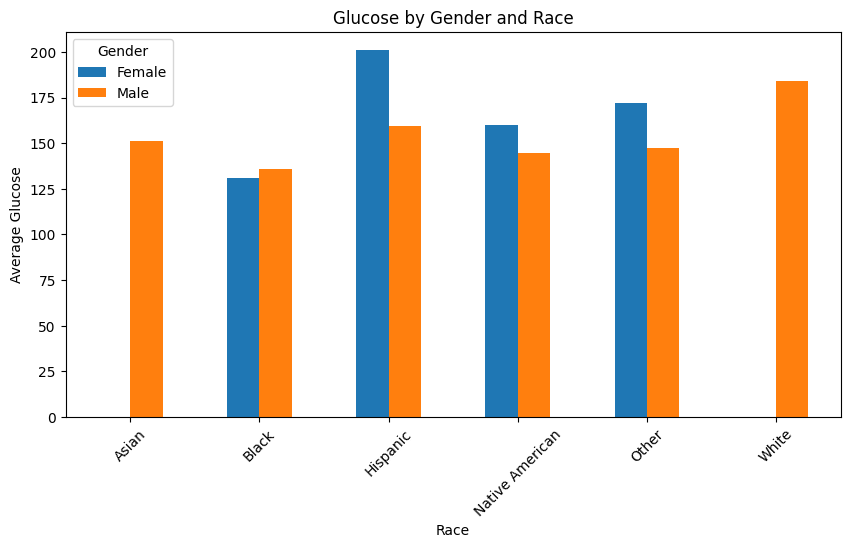

In [15]:
gender_race_glucose.plot(kind='bar', figsize=(10,5))
plt.title("Glucose by Gender and Race")
plt.ylabel("Average Glucose")
plt.xticks(rotation=45)
plt.show()

Insight:
The bar chart compares average glucose levels across different gender and race groups, helping identify patterns in glucose variation among demographic categories. Differences in bar heights indicate that some groups have higher average glucose levels than others, which may suggest varying diabetes risk profiles across populations. These variations could be influenced by factors such as lifestyle, diet, genetics, or health conditions. This analysis helps highlight demographic groups that may benefit from targeted health monitoring and preventive care.

Percentage of Participants with Sleep Disturbances

In [18]:
print(df['% with Sleep Disturbances'].head())

0    40
1    40
2    40
3    40
4    40
Name: % with Sleep Disturbances, dtype: int64


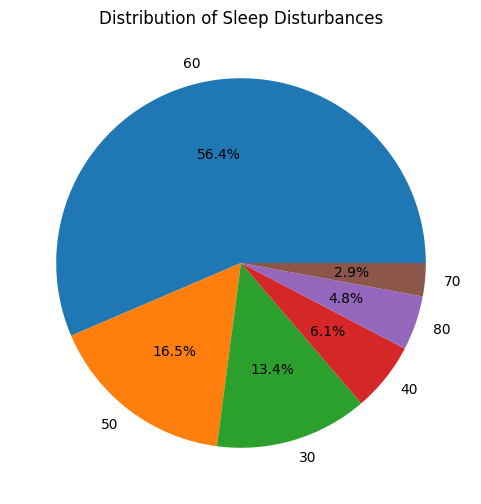

In [19]:
import matplotlib.pyplot as plt

dist_counts = df['% with Sleep Disturbances'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(dist_counts, labels=dist_counts.index, autopct='%1.1f%%')

plt.title("Distribution of Sleep Disturbances")
plt.show()

Insight:
The pie chart illustrates the distribution of participants experiencing different levels of sleep disturbances. It helps identify whether sleep disturbances are common or less frequent within the dataset. A larger percentage in higher disturbance categories may indicate widespread sleep-related issues among participants, which could potentially impact overall health, glucose regulation, and daily activity levels. This visualization helps highlight the prevalence of sleep disturbances and their importance as a health factor.

Percentage Breakdown of Normal, Prediabetic, and Diabetic Glucose Categories

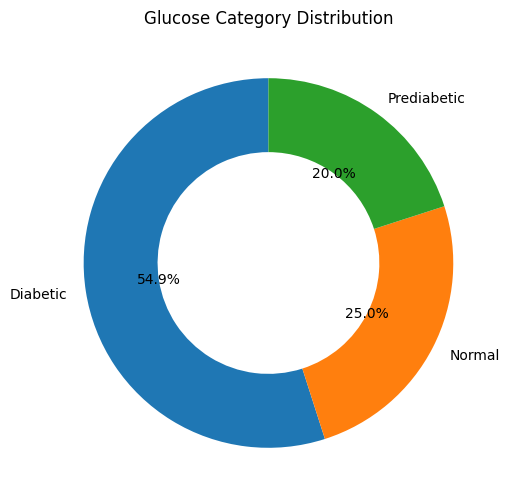

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# assume your dataframe is df and glucose column is 'glucose'

def classify_glucose(g):
    if g < 100:
        return "Normal"
    elif g < 126:
        return "Prediabetic"
    else:
        return "Diabetic"

df["Glucose_Category"] = df["glucose"].apply(classify_glucose)

# count categories
counts = df["Glucose_Category"].value_counts()

# donut chart
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}  # makes it donut shape
)

plt.title("Glucose Category Distribution")
plt.show()

 The donut chart shows the percentage distribution of participants across glucose risk categories: Normal, Prediabetic, and Diabetic. It provides a clear overview of how glucose levels are spread within the population. A higher proportion in the Normal category indicates a generally healthy population, while noticeable portions in Prediabetic or Diabetic categories highlight potential metabolic health risks. This visualization helps quickly assess the overall diabetes risk profile of the dataset.